In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import os
os.environ['PATH'] += os.pathsep + r'd:\ai_env\Library\bin'
os.environ['CUDA_PATH'] = r'd:\ai_env'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_path = '../dataset/train'
test_path = '../dataset/test'

train_generator = datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
)

validation_generator = datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False 
)

checkpoint_callback = ModelCheckpoint(
    filepath=r'D:\EmotionProject\models\best_model.h5', 
    monitor='val_accuracy',       
    save_best_only=True,         
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6
)

callbacks_list = [checkpoint_callback, early_stop, reduce_lr]

Found 39559 images belonging to 7 classes.
Found 9886 images belonging to 7 classes.
Found 1001 images belonging to 7 classes.


In [ ]:
import plotly.graph_objects as go
import pandas as pd
import os

train_path = '../dataset/train'
test_path = '../dataset/test'
emotion_categories = sorted(os.listdir(train_path))

# Збір даних
emotion_categories = sorted([d for d in os.listdir(train_path) 
                                if os.path.isdir(os.path.join(train_path, d))])

train_counts = [len(os.listdir(os.path.join(train_path, cat))) for cat in emotion_categories]
test_counts = [len(os.listdir(os.path.join(test_path, cat))) for cat in emotion_categories]

fig = go.Figure(data=[
    go.Bar(name='Train', x=emotion_categories, y=train_counts, text=train_counts, textposition='auto'),
    go.Bar(name='Test', x=emotion_categories, y=test_counts, text=test_counts, textposition='auto')
])

fig.update_layout(
    title='Розподіл зображень за категоріями емоцій',
    xaxis_title='Категорії емоцій',
    yaxis_title='Кількість зображень',
    barmode='group', 
    template='plotly_dark'
)

fig.show()

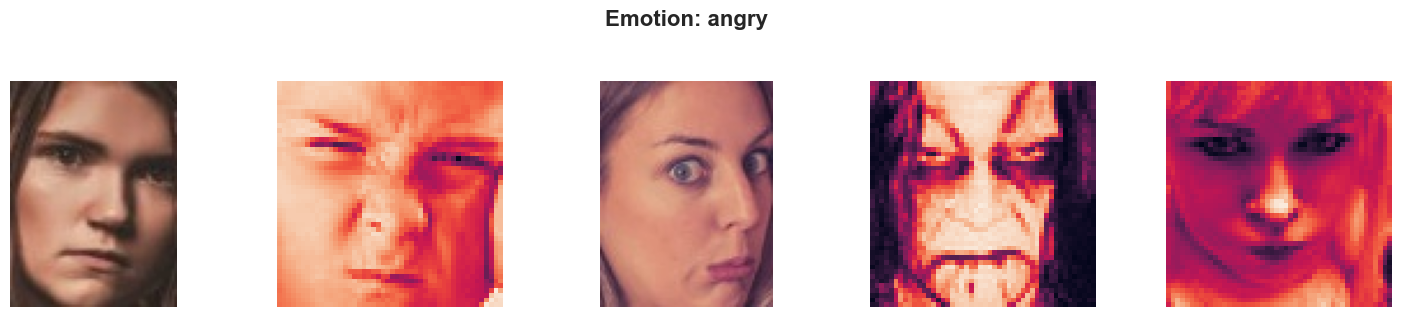

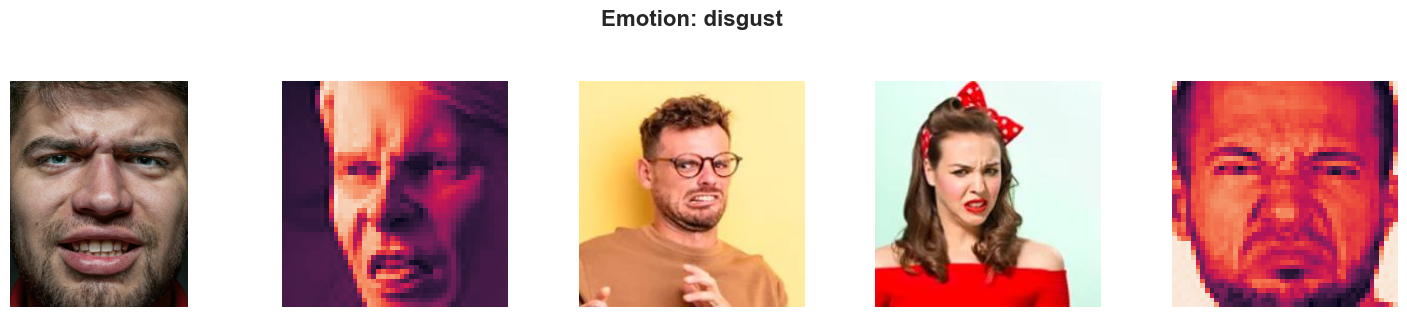

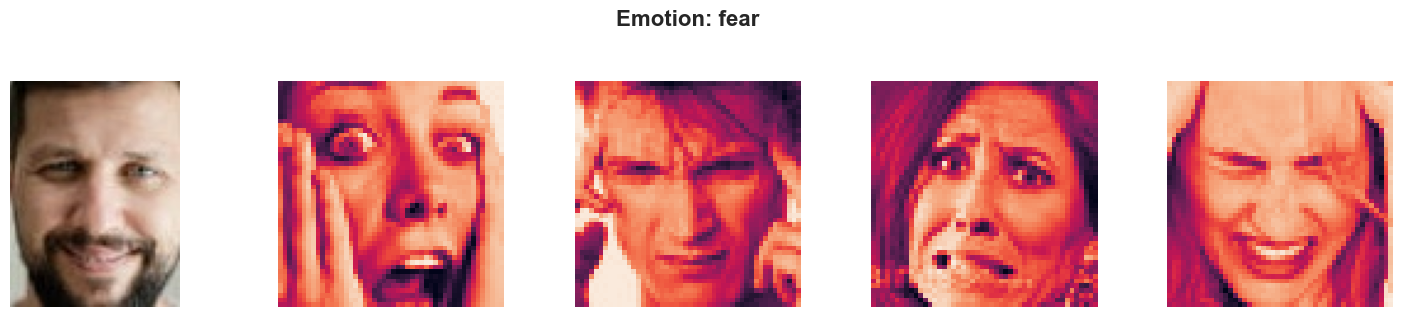

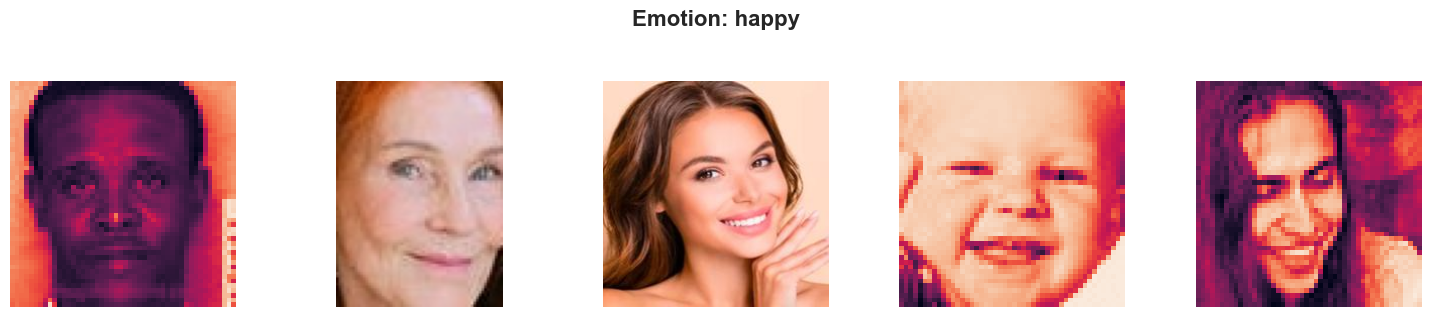

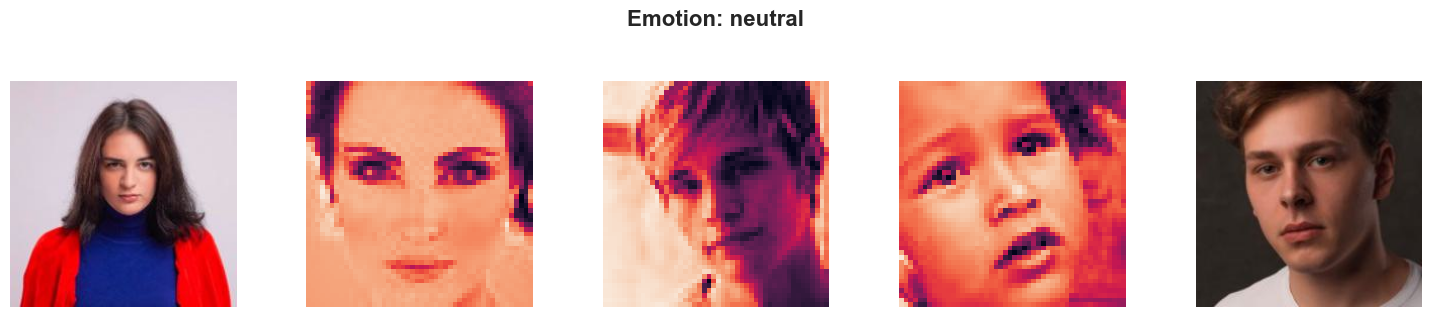

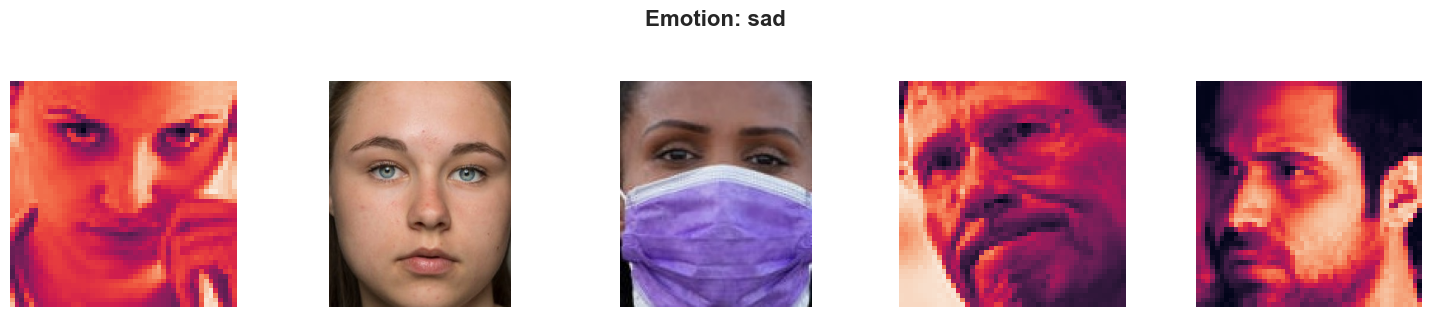

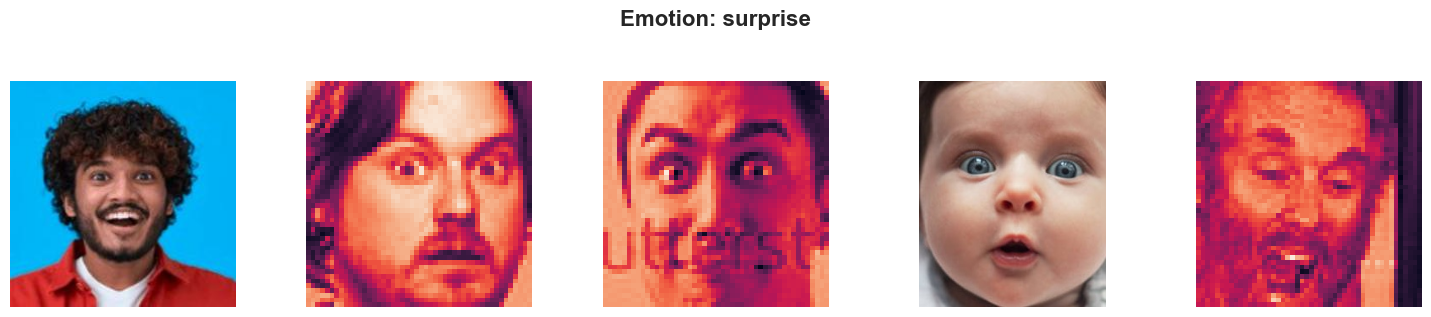

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
import random

sns.set_theme(style="dark", palette="pastel")

def plot_sample_images(emotion, img_paths, num_images=5):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))
    fig.suptitle(f"Emotion: {emotion}", fontsize=16, fontweight='bold', y=1.05)
    
    for i, img_path in enumerate(img_paths):
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

data_path = '../dataset/train'

for emotion in emotion_categories:
    emotion_path = os.path.join(data_path, emotion)
    
    if os.path.exists(emotion_path):
        all_img_files = [f for f in os.listdir(emotion_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        random_img_files = random.sample(all_img_files, min(len(all_img_files), 5))
        img_paths = [os.path.join(emotion_path, img_file) for img_file in random_img_files]
        
        plot_sample_images(emotion, img_paths)
    else:
        print(f"Папку {emotion} не знайдено за шляхом {emotion_path}")

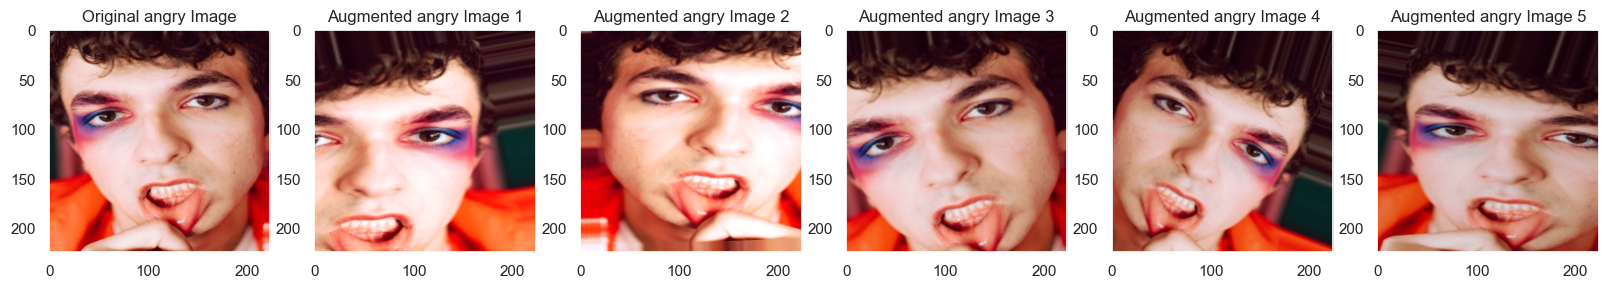

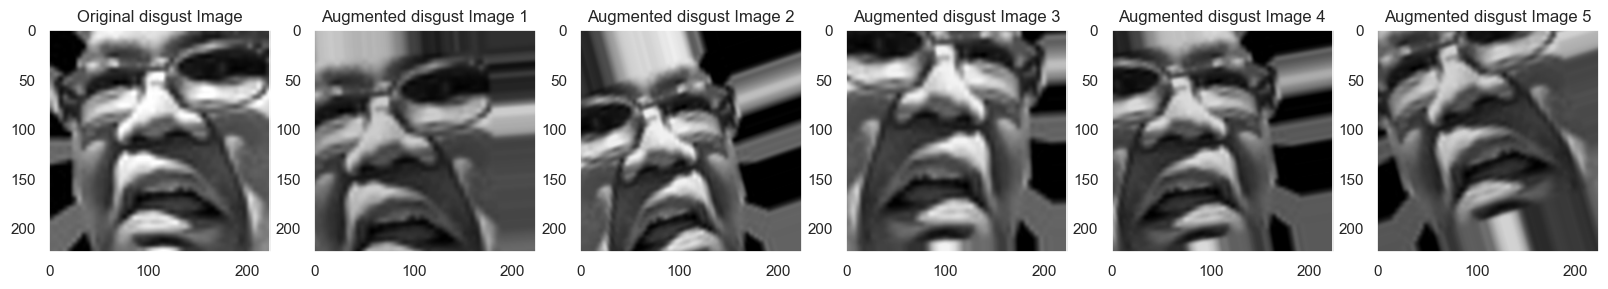

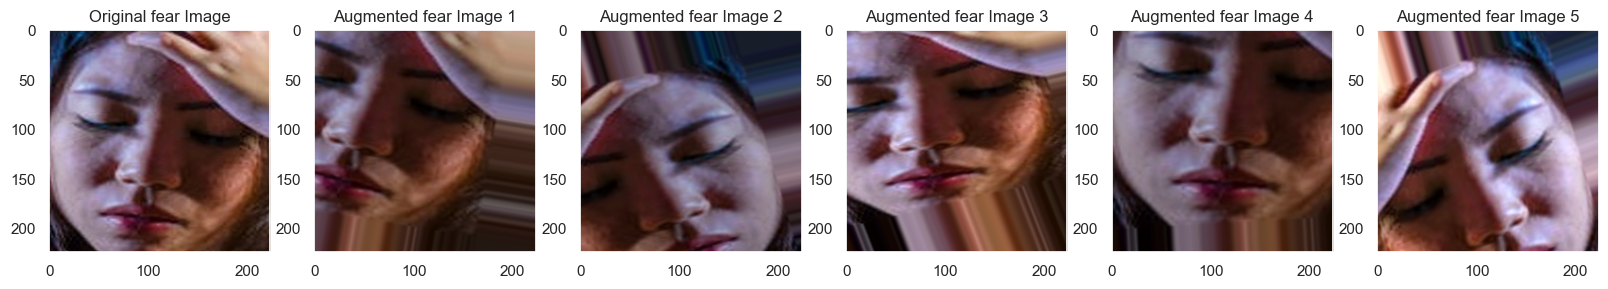

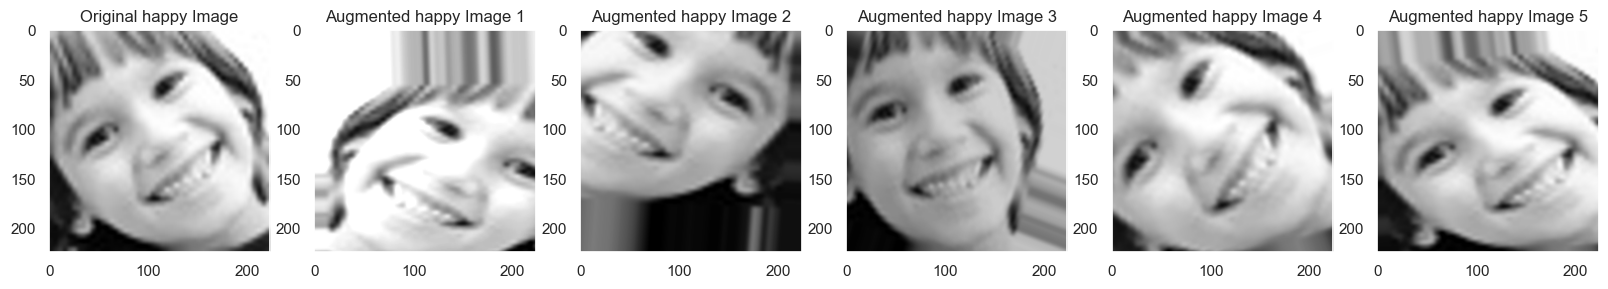

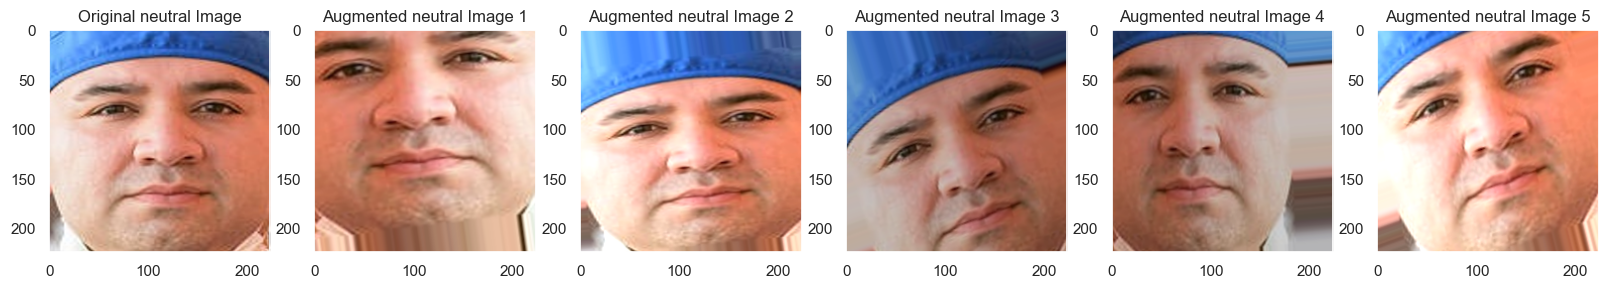

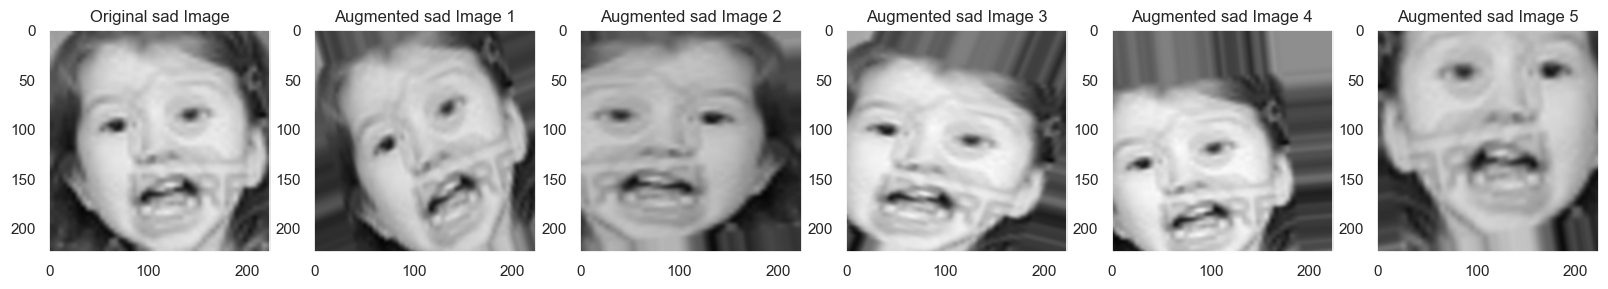

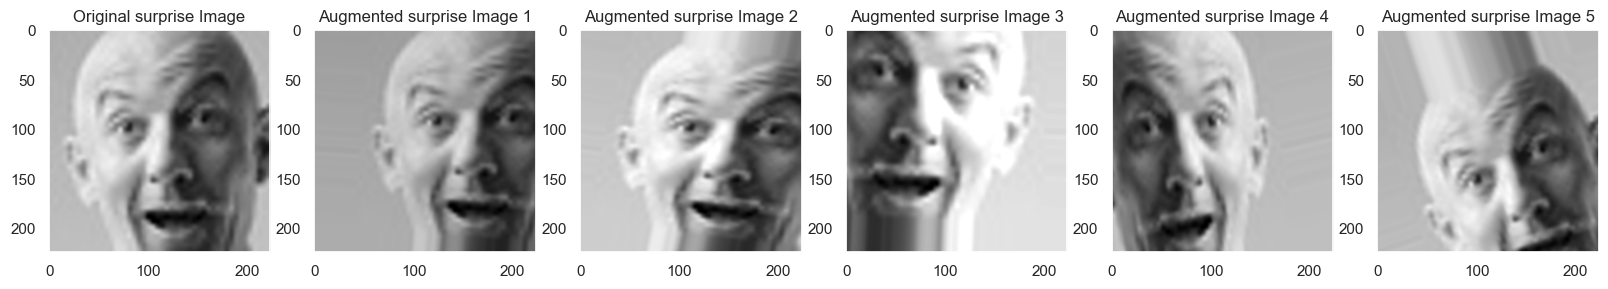

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
import random

datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20, 
    width_shift_range=0.2,  
    height_shift_range=0.2, 
    brightness_range=[0.8, 1.2], 
    shear_range=0.2,
    zoom_range=0.2, 
    horizontal_flip=True,  
    fill_mode='nearest'
)

for emotion in emotion_categories:
    emotion_path = os.path.join(train_path, emotion)
    img_name = random.choice(os.listdir(emotion_path))
    img_path = os.path.join(emotion_path, img_name)

    img = Image.open(img_path).resize((224, 224))
    img = img.convert('RGB')  
    img = np.array(img)
    img = img.reshape((1, 224, 224, 3))

    augmented_imgs = [datagen.flow(img, batch_size=1).__next__()[0] for _ in range(5)]

    fig, axes = plt.subplots(1, 6, figsize=(20, 5))
    axes[0].imshow(img[0].astype('uint8'))
    axes[0].set_title(f"Original {emotion} Image")

    for i, aug_img in enumerate(augmented_imgs):
        aug_img = (aug_img * 255).astype('uint8') 
        axes[i + 1].imshow(aug_img)
        axes[i + 1].set_title(f"Augmented {emotion} Image {i+1}")

    plt.show()

In [5]:
import tensorflow as tf
from tensorflow.keras.applications import ConvNeXtBase
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Activation, Conv2D, Concatenate
from tensorflow.keras.models import Model

precision_metric = tf.keras.metrics.Precision()
recall_metric = tf.keras.metrics.Recall()

def f1_score(y_true, y_pred):
    p = precision_metric(y_true, y_pred)
    r = recall_metric(y_true, y_pred)
    return 2 * ((p * r) / (p + r + tf.keras.backend.epsilon()))

def spatial_attention_block(inputs):
    avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
    max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)
    concat = Concatenate(axis=-1)([avg_pool, max_pool])
    attention = Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)
    return inputs * attention

base_model = ConvNeXtBase(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False 

x = base_model.output
x = spatial_attention_block(x) 
x = GlobalAveragePooling2D()(x)

x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(7, activation='softmax', name='predictions')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', precision_metric, recall_metric, f1_score]
)

print("Модель успішно зібрана у режимі float32!")

Модель успішно зібрана у режимі float32!


In [6]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 convnext_base_prestem_normaliz  (None, 224, 224, 3)  0          ['input_1[0][0]']                
 ation (Normalization)                                                                            
                                                                                                  
 convnext_base_stem (Sequential  (None, 56, 56, 128)  6528       ['convnext_base_prestem_normaliza
 )                                                               tion[0][0]']                 

In [7]:

tf.config.optimizer.set_jit(False)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', precision_metric, recall_metric, f1_score]
)
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=4,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

model.save(r'D:\EmotionProject\models\imageclassifier.h5')

Epoch 1/4
1236/1236 [==============================] - 1321s 1s/step - loss: 1.2904 - accuracy: 0.5119 - precision: 0.6831 - recall: 0.3024 - f1_score: 0.3648 - val_loss: 1.4378 - val_accuracy: 0.4925 - val_precision: 0.6947 - val_recall: 0.2636 - val_f1_score: 0.3898
Epoch 2/4
1236/1236 [==============================] - 1299s 1s/step - loss: 1.1570 - accuracy: 0.5582 - precision: 0.7100 - recall: 0.3766 - f1_score: 0.4871 - val_loss: 1.4052 - val_accuracy: 0.5037 - val_precision: 0.7270 - val_recall: 0.2704 - val_f1_score: 0.3943
Epoch 3/4
1236/1236 [==============================] - 1300s 1s/step - loss: 1.1209 - accuracy: 0.5746 - precision: 0.7222 - recall: 0.3995 - f1_score: 0.5176 - val_loss: 1.4217 - val_accuracy: 0.5064 - val_precision: 0.7065 - val_recall: 0.3041 - val_f1_score: 0.4261
Epoch 4/4
1236/1236 [==============================] - 1298s 1s/step - loss: 1.0945 - accuracy: 0.5831 - precision: 0.7299 - recall: 0.4135 - f1_score: 0.5267 - val_loss: 1.3793 - val_accuracy: